### Host predictions for CF detected v active viruses

In [1]:
### Load packages
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

In [2]:
### load phist + crispr host information
uhvdb_phisttaxa = pl.read_csv('../figure_4/uhvdb_r2025_10_species_phist_host_predictions.tsv', separator='\t')
uhvdb_crisprtaxa = pl.read_csv('../figure_4/uhvdb_r2025_10_species_spacer_host_predictions.tsv', separator='\t')

In [3]:
### prioritize crispr when available
uhvdb_combinedtaxa_og = (
    uhvdb_phisttaxa[['votu_rep', 'consensus_species', 'species_max_count', 'consensus_genus', 'genus_max_count', 'consensus_family', 'family_max_count']]
        .join(
            uhvdb_crisprtaxa[['votu_rep', 'consensus_species', 'species_max_count', 'consensus_genus', 'genus_max_count', 'consensus_family', 'family_max_count']],
            on='votu_rep',
            how='full',
            suffix='_crispr'
        )
        .with_columns([
            pl.col('species_max_count').fill_null(0).alias('species_max_count'),
            pl.col('genus_max_count').fill_null(0).alias('genus_max_count'),
            pl.col('family_max_count').fill_null(0).alias('family_max_count'),
            pl.col('species_max_count_crispr').fill_null(0).alias('species_max_count_crispr'),
            pl.col('genus_max_count_crispr').fill_null(0).alias('genus_max_count_crispr'),
            pl.col('family_max_count_crispr').fill_null(0).alias('family_max_count_crispr'),
        ])
        .with_columns([
            pl.when((pl.col('consensus_species').is_not_null()) & (pl.col('species_max_count') > pl.col('species_max_count_crispr'))).then(pl.col('consensus_species'))
                .when(pl.col('consensus_species_crispr').is_not_null()).then(pl.col('consensus_species_crispr'))
                .otherwise(pl.lit(None)).alias('species'),
            pl.when((pl.col('consensus_genus').is_not_null()) & (pl.col('genus_max_count') > pl.col('genus_max_count_crispr'))).then(pl.col('consensus_genus'))
                .when(pl.col('consensus_genus_crispr').is_not_null()).then(pl.col('consensus_genus_crispr'))
                .otherwise(pl.lit(None)).alias('genus'),
            pl.when((pl.col('consensus_family').is_not_null()) & (pl.col('family_max_count') > pl.col('family_max_count_crispr'))).then(pl.col('consensus_family'))
                .when(pl.col('consensus_family_crispr').is_not_null()).then(pl.col('consensus_family_crispr'))
                .otherwise(pl.lit(None)).alias('family'),
        ])
)

In [4]:
atb_hosts = pl.read_csv('../uhvdb_cf_supplement/cf_pathogen_biosamples.csv').filter(pl.col('Sequence_abundance') >= 50)
uhvdb_combinedtaxa = (
    uhvdb_combinedtaxa_og
        .with_columns([
            pl.when(pl.col('votu_rep').str.contains(r'SAM.*\.contig')).then(pl.col('votu_rep').str.extract(r'(SAM.*)\.contig', 1))
                .alias('sample_accession')
        ])
        .join(atb_hosts, on='sample_accession', how='left')
        .with_columns([
            pl.when(pl.col('Species').is_not_null()).then(pl.col('Species')).otherwise(pl.col('species'))
                .alias('species'),
            pl.when(pl.col('Species').is_not_null()).then(pl.col('Species').str.split(' ').list[0]).otherwise(pl.col('genus'))
                .alias('genus')
        ])
)

In [5]:
uhvdb_combinedtaxa.write_csv('uhvdb_r2025_10_species_combined_host_predictions.tsv', separator='\t')

In [6]:
### Identify viruses detected in CF metagenomes
activity_data = (
    pl.read_csv('cf_metagenome_virus_activity_data.tsv', separator='\t')
        .filter(pl.col('breadth_ratio') >= 0.6)
)

In [7]:
### Extract CF viruses from host data
uhvdb_combinedtaxa_cf = (
    uhvdb_combinedtaxa
        .join(activity_data, left_on='votu_rep', right_on='contig_id', how='right')
)

In [8]:
### Count prop of host assignments at each rank
print(uhvdb_combinedtaxa_cf.filter(pl.col('species').is_not_null()).height/uhvdb_combinedtaxa_cf.height)
print(uhvdb_combinedtaxa_cf.filter(pl.col('genus').is_not_null()).height/uhvdb_combinedtaxa_cf.height)
print(uhvdb_combinedtaxa_cf.filter(pl.col('family').is_not_null()).height/uhvdb_combinedtaxa_cf.height)

0.5531476565904679
0.9450101026108316
0.9548948139931065


In [9]:
### Categorize CF viruses by their activity
cat_activity = pl.concat([
    uhvdb_combinedtaxa_cf
        .with_columns([
            pl.when(pl.col('activity_score') >= 3).then(pl.lit('High-confidence'))
            .when(pl.col('activity_score') >= 1).then(pl.lit('Low-confidence'))
            .otherwise(pl.lit('Unknown'))
            .alias('activity_category')
        ])
])

In [10]:
### Count prop of host assignments at each rank
print(cat_activity.filter(pl.col('species').is_not_null()).filter(pl.col('activity_category') == 'High-confidence').height/cat_activity.filter(pl.col('activity_category') == 'High-confidence').height)
print(cat_activity.filter(pl.col('genus').is_not_null()).filter(pl.col('activity_category') == 'High-confidence').height/cat_activity.filter(pl.col('activity_category') == 'High-confidence').height)
print(cat_activity.filter(pl.col('family').is_not_null()).filter(pl.col('activity_category') == 'High-confidence').height/cat_activity.filter(pl.col('activity_category') == 'High-confidence').height)

0.5033557046979866
0.9378465129851182
0.9573971403559965


In [11]:
### Get top 10 host families overall
top_10_families = (
    cat_activity
        .filter(pl.col('family').is_not_null())
        .group_by('family')
        .len()
        .sort('len', descending=True)
        .head(10)['family']
)

# Classify families as top 10 or "Other"
host_family_classified = (
    cat_activity
        .with_columns([
            pl.when(pl.col('family').is_in(top_10_families)).then(pl.col('family'))
                .when(pl.col('family').is_null()).then(pl.lit('No host prediction'))
                .otherwise(pl.lit('Other'))
                .alias('family_classified')
        ])
)

uhvdb_host_annotations = (
    host_family_classified
        .group_by(['activity_category', 'family_classified'])
        .len()
)

/tmp/ipykernel_31592/1431233322.py:14: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([


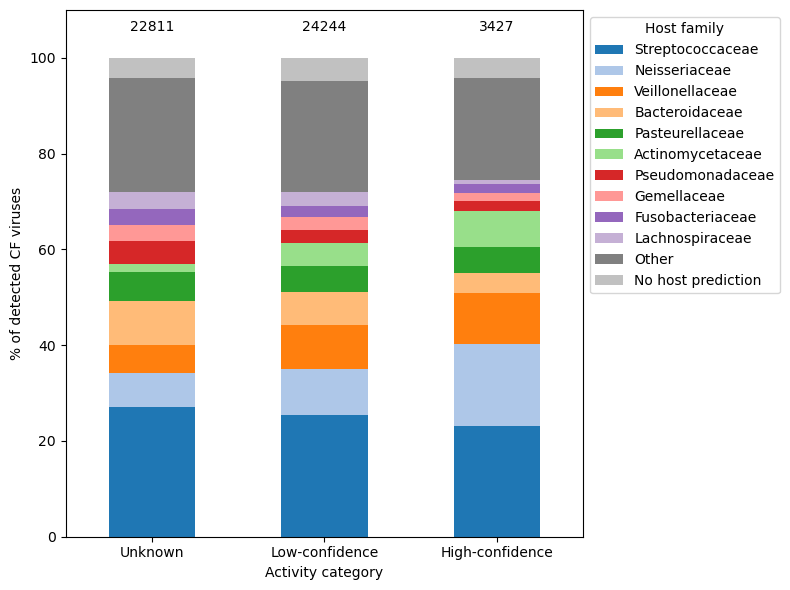

In [12]:
# Create stacked bar chart showing host family distribution by activity status
family_by_site = (
    uhvdb_host_annotations
        .pivot(index='activity_category', on='family_classified', values='len', aggregate_function='sum')
        .fill_null(0)
)

# Convert to pandas for easier manipulation
family_by_site_pd = family_by_site.to_pandas().set_index('activity_category')

# Calculate total counts per body site
totals = family_by_site_pd.sum(axis=1)

# Calculate proportions (normalize to 100%)
family_proportions = family_by_site_pd.div(totals, axis=0) * 100

# Order families by average abundance (greatest to least, excluding Other and No host prediction)
family_avg = family_proportions.mean().sort_values(ascending=False)
# Remove 'Other' and 'No host prediction' from ordering
exclude_cols = []
if 'Other' in family_avg.index:
    exclude_cols.append('Other')
if 'No host prediction' in family_avg.index:
    exclude_cols.append('No host prediction')

family_avg_filtered = family_avg.drop(exclude_cols) if exclude_cols else family_avg
# Order: highest abundance at bottom (first), lowest at top, Other, then No host prediction at very top
ordered_cols = family_avg_filtered.sort_values(ascending=False).index.tolist()
if 'Other' in family_avg.index:
    ordered_cols.append('Other')
if 'No host prediction' in family_avg.index:
    ordered_cols.append('No host prediction')

family_proportions = family_proportions[ordered_cols]

# Create custom color palette - use default colors for families, grey for Other, white for No host prediction
import matplotlib.cm as cm
n_families = len(family_proportions.columns)
# Subtract special categories from color count
if 'Other' in family_proportions.columns:
    n_families -= 1
if 'No host prediction' in family_proportions.columns:
    n_families -= 1

colors = list(plt.cm.tab20.colors[:n_families])
if 'Other' in family_proportions.columns:
    colors.append('#808080')  # Add grey for Other
if 'No host prediction' in family_proportions.columns:
    colors.append("#C1C1C1")  # Add white for No host prediction

# Create stacked bar chart with proportions
activity_order = ['Unknown', 'Low-confidence', 'High-confidence']
family_proportions = family_proportions.reindex(activity_order)
ax = family_proportions.plot(kind='bar', stacked=True, figsize=(8, 6), color=colors)
plt.xticks(rotation=0)
plt.xlabel('Activity category')
plt.ylabel('% of detected CF viruses')
plt.legend(title='Host family', bbox_to_anchor=(1.0, 1), loc='upper left')

# Add total counts above each bar
for i, total in enumerate(totals.reindex(activity_order)):
    ax.text(i, 105, str(total), ha='center', va='bottom', fontsize=10)

plt.ylim(0, 110)  # Make room for the count labels
plt.tight_layout()
plt.show()

In [13]:
high_prev = set(pl.read_csv('high_prev_cf_viruses.tsv', separator='\t')['contig_id'])

uhvdb_combinedtaxa_cf.filter(pl.col('contig_id').is_in(high_prev))[['species', 'genus', 'contig_id']].unique('contig_id').write_csv('high_prev_cf_virus_host.tsv', separator='\t')

In [15]:
high_cov = set(pl.read_csv('cf_pathogen_cov_active.tsv', separator='\t')['contig_id'])

uhvdb_combinedtaxa_cf.filter(pl.col('contig_id').is_in(high_cov))[['species', 'genus', 'contig_id']].unique('contig_id').write_csv('high_cov_cf_virus_host.tsv', separator='\t')

In [130]:
plot_df = (
    uhvdb_combinedtaxa.select(['votu_rep', 'genus'])
        .unique('votu_rep')
        .join(pl.read_csv('cf_pathogen_dom_viruses.tsv', separator='\t'), left_on='votu_rep', right_on='contig_id', how='inner')
        .sort('votu_rep')
        .with_columns([
            pl.col('genus_right').str.replace('g__', '').alias('genus_right'),
        ])
)

# calculate agreement
plot_df = (
    plot_df
    .with_columns([
        pl.when(pl.col('genus') == pl.col('genus_right')).then(pl.lit('Agreement')).otherwise(pl.lit('Disagreement')).alias('agreement')
    ])
)

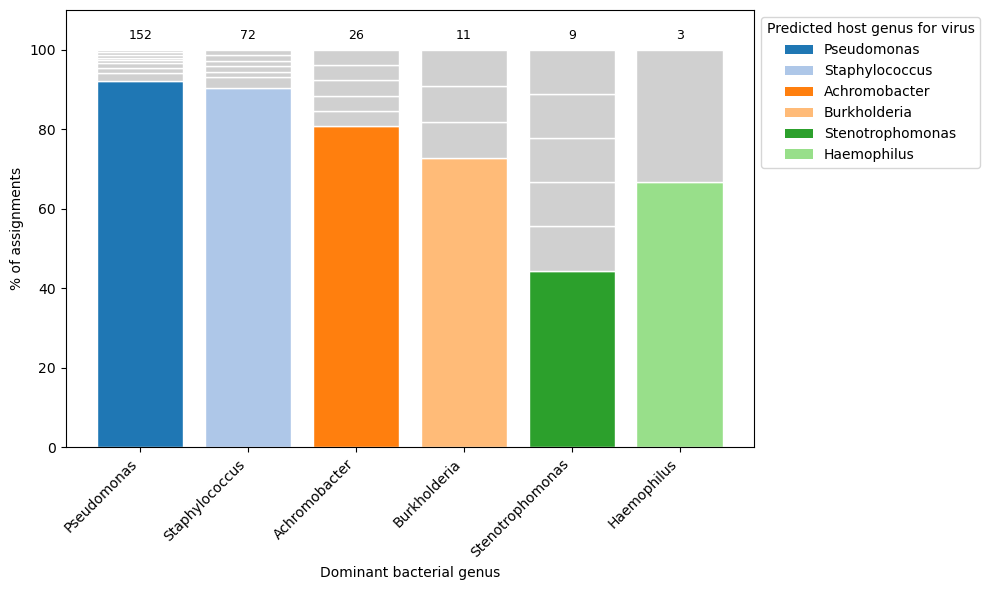

In [128]:
# Proportions of host genus (left) within each genus_right
import pandas as pd
from matplotlib.patches import Patch

genus_df = (
    plot_df
        .filter(pl.col('genus').is_not_null() & pl.col('genus_right').is_not_null())
        .select(['genus', 'genus_right'])
        .to_pandas()
 )

# Crosstab normalized by genus_right (rows)
genus_prop = pd.crosstab(genus_df['genus_right'], genus_df['genus'], normalize='index') * 100

# Order genus_right by total counts (largest first)
genus_counts = genus_df['genus_right'].value_counts()
genus_prop = genus_prop.loc[genus_counts.index]

# Color only matching genera; others are grey
palette = list(plt.cm.tab20.colors)
color_map = {g: palette[i % len(palette)] for i, g in enumerate(genus_prop.index)}
other_color = '#D0D0D0'

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(genus_prop.index))
bar_width = 0.8

for i, genus_right in enumerate(genus_prop.index):
    bottom = 0
    row = genus_prop.loc[genus_right]
    # Sort segments so largest proportion is at the bottom for each bar
    row_sorted = row.sort_values(ascending=False)
    for genus, val in row_sorted.items():
        if val == 0:
            continue
        color = color_map[genus_right] if genus == genus_right else other_color
        ax.bar(i, val, bottom=bottom, color=color, edgecolor='white', width=bar_width)
        bottom += val

# Labels and totals
ax.set_xticks(x_pos)
ax.set_xticklabels(genus_prop.index, rotation=45, ha='right')
ax.set_xlabel('Dominant bacterial genus')
ax.set_ylabel('% of assignments')
ax.set_ylim(0, 110)
for i, total in enumerate(genus_counts):
    ax.text(i, 102, str(total), va='bottom', ha='center', fontsize=9)

# Legend for matching genera only
handles = [Patch(facecolor=color_map[g], label=g) for g in genus_prop.index]
ax.legend(handles=handles, title='Predicted host genus for virus', bbox_to_anchor=(1.0, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [129]:
print("% agreement at genus level:", (plot_df.filter(pl.col('agreement') == 'Agreement').filter(pl.col('genus').is_not_null()).height / plot_df.filter(pl.col('genus').is_not_null()).height) * 100)

% agreement at genus level: 87.91208791208791
